In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , precision_score,recall_score,f1_score,roc_auc_score

In [2]:
df = pd.read_csv("../dataset/diabetic_cleaned.csv")
x = df.drop(columns=["readmitted", "readmitted_binary"])
y = df["readmitted_binary"]
x = pd.get_dummies(x, drop_first=True)
import joblib
feature_names = x.columns.tolist()
joblib.dump(feature_names, "trained_feature_columns.pkl")

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Impute missing values on X_train to prevent data leakage
for col in x_train.columns:
    if not x_train[col].isnull().any() and not x_test[col].isnull().any():
        continue
    if pd.api.types.is_numeric_dtype(x_train[col]):
        fill_val = x_train[col].median()
    else:
        mode_vals = x_train[col].mode(dropna=True)
        fill_val = mode_vals.iloc[0] if len(mode_vals) else "Unknown"
    x_train[col] = x_train[col].fillna(fill_val)
    x_test[col] = x_test[col].fillna(fill_val)
print(f"X_train shape: {x_train.shape} | X_test shape: {x_test.shape}")

X_train shape: (56351, 2262) | X_test shape: (14088, 2262)


In [3]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications']

for col in num_cols:
    print(f"--- Feature: {col} ---")
    print(f"Train Mean: {x_train[col].mean():.2f}  | Test Mean: {x_test[col].mean():.2f}")
    print(f"Train Var:  {x_train[col].var():.2f}  | Test Var:  {x_test[col].var():.2f}")
    print()

--- Feature: time_in_hospital ---
Train Mean: 4.28  | Test Mean: 4.29
Train Var:  8.65  | Test Var:  8.59

--- Feature: num_lab_procedures ---
Train Mean: 42.90  | Test Mean: 42.97
Train Var:  396.90  | Test Var:  392.94

--- Feature: num_procedures ---
Train Mean: 1.43  | Test Mean: 1.41
Train Var:  3.09  | Test Var:  3.02

--- Feature: num_medications ---
Train Mean: 15.67  | Test Mean: 15.66
Train Var:  69.18  | Test Var:  66.31



In [4]:
# Logestic Regressinon
linear_model=LogisticRegression(class_weight='balanced', max_iter=1000)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
linear_model.fit(x_train,y_train)

y_pred=linear_model.predict(x_test)

print("classifier report: ",classification_report(y_test,y_pred))
print("confusion matrix: ",confusion_matrix(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("roc_auc_score: ",roc_auc_score(y_test,y_pred))
print("precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))


classifier report:                precision    recall  f1-score   support

           0       0.93      0.64      0.76     12829
           1       0.12      0.51      0.20      1259

    accuracy                           0.63     14088
   macro avg       0.53      0.58      0.48     14088
weighted avg       0.86      0.63      0.71     14088

confusion matrix:  [[8192 4637]
 [ 615  644]]
accuracy:  0.6272004542873367
roc_auc_score:  0.5750351773877084
precision:  0.12194660102253362
recall:  0.511517077045274
f1_score:  0.19694189602446482


In [5]:
# Decision tree
tree_model=DecisionTreeClassifier(class_weight='balanced', random_state=42)
tree_model.fit(x_train,y_train)

y_pred=tree_model.predict(x_test)

print("classifier report: ",classification_report(y_test,y_pred))
print("confusion matrix: ",confusion_matrix(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("roc_auc_score: ",roc_auc_score(y_test,y_pred))
print("precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))


classifier report:                precision    recall  f1-score   support

           0       0.92      0.88      0.90     12829
           1       0.12      0.17      0.14      1259

    accuracy                           0.82     14088
   macro avg       0.52      0.53      0.52     14088
weighted avg       0.84      0.82      0.83     14088

confusion matrix:  [[11316  1513]
 [ 1044   215]]
accuracy:  0.8184980124929018
roc_auc_score:  0.526417263161779
precision:  0.1244212962962963
recall:  0.17077045274027006
f1_score:  0.14395714763977235


In [6]:
# Random Forest
ensemble_model=RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_estimators=300, max_depth=6,)
ensemble_model.fit(x_train,y_train)

y_pred=ensemble_model.predict(x_test)

print("classifier report: ",classification_report(y_test,y_pred))
print("confusion matrix: ",confusion_matrix(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("roc_auc_score: ",roc_auc_score(y_test,y_pred))
print("precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))

classifier report:                precision    recall  f1-score   support

           0       0.94      0.63      0.75     12829
           1       0.13      0.58      0.22      1259

    accuracy                           0.62     14088
   macro avg       0.54      0.60      0.48     14088
weighted avg       0.87      0.62      0.70     14088

confusion matrix:  [[8034 4795]
 [ 526  733]]
accuracy:  0.6223026689381034
roc_auc_score:  0.6042227662443935
precision:  0.13259768451519538
recall:  0.5822081016679904
f1_score:  0.21600117872403124


In [7]:
# XGBoost
xgboost_model=XGBClassifier(learning_rate=0.05, max_depth=6,scale_pos_weight=8, eval_metric="logloss", n_estimators=300, random_state=42)
xgboost_model.fit(x_train,y_train)

y_pred=xgboost_model.predict(x_test)

# Calculate optimal threshold for F1-score
from sklearn.metrics import precision_recall_curve
y_probs = xgboost_model.predict_proba(x_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = (2 * precisions * recalls) / (precisions + recalls)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Risk Threshold: {optimal_threshold:.3f}")
print(f"Maximized F1-Score: {f1_scores[optimal_idx]:.3f}")

print("classifier report: ",classification_report(y_test,y_pred))
print("confusion matrix: ",confusion_matrix(y_test,y_pred))
print("accuracy: ",accuracy_score(y_test,y_pred))
print("roc_auc_score: ",roc_auc_score(y_test,y_pred))
print("precision: ",precision_score(y_test,y_pred))
print("recall: ",recall_score(y_test,y_pred))
print("f1_score: ",f1_score(y_test,y_pred))

Optimal Risk Threshold: 0.492
Maximized F1-Score: 0.243
classifier report:                precision    recall  f1-score   support

           0       0.93      0.84      0.88     12829
           1       0.18      0.35      0.24      1259

    accuracy                           0.80     14088
   macro avg       0.55      0.59      0.56     14088
weighted avg       0.86      0.80      0.83     14088

confusion matrix:  [[10810  2019]
 [  822   437]]
accuracy:  0.7983390119250426
roc_auc_score:  0.5948615289117047
precision:  0.1779315960912052
recall:  0.3471008737092931
f1_score:  0.23526244952893674


C:\Users\prane\AppData\Local\Temp\ipykernel_14192\2553005194.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


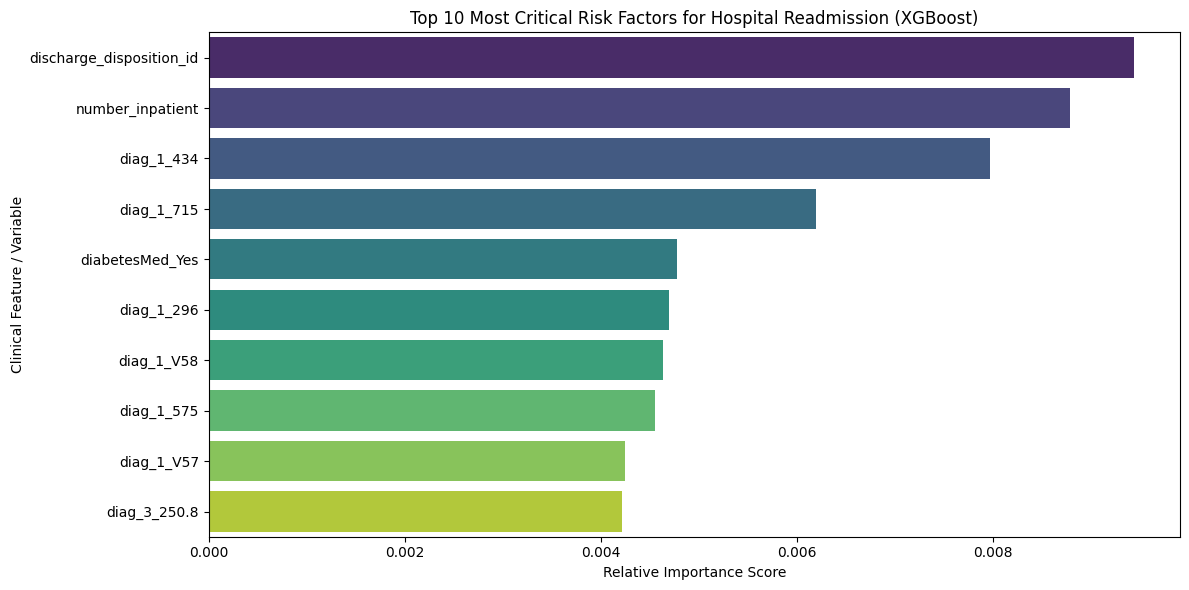

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the 2,262 importance scores from your trained model
importances = xgboost_model.feature_importances_

# 2. Automatically find the DataFrame before scaling to pull the names.
# Look back at your notebook: what was the name of the DataFrame you ran pd.get_dummies() on?
# Let's say it was called 'X_encoded' or 'X'. We pull its columns list:
try:
    # If your master features DataFrame before splitting/scaling was named 'X'
    feature_names = X.columns
except NameError:
    # If you named your master encoded features lowercase 'x' before scaling
    feature_names = x.columns

# 3. Create the mapping DataFrame safely
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 4. Sort and grab the top 10 rows
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# 5. Plot the final chart
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Most Critical Risk Factors for Hospital Readmission (XGBoost)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Clinical Feature / Variable')
plt.tight_layout()
plt.show()

In [9]:
import joblib

joblib.dump(xgboost_model, 'hospital_readmission_xgb_v1.pkl')

joblib.dump(scaler, 'hospital_data_scaler.pkl')

['hospital_data_scaler.pkl']

In [10]:
def predict_new_patient(raw_patient_data):

    model = joblib.load('hospital_readmission_xgb_model.pkl')
    expected_features = joblib.load('trained_feature_columns.pkl')
    
    single_df = pd.DataFrame([raw_patient_data])
    
    single_encoded = pd.get_dummies(single_df)
    
    final_features = single_encoded.reindex(columns=expected_features, fill_value=0)
    
    risk_probability = model.predict_proba(final_features)[0][1]
    
    if risk_probability > 0.40:
        return {
            "status": "⚠️ HIGH RISK ALERT",
            "probability": f"{risk_probability * 100:.1f}%",
            "action": "Recommend delayed discharge, home health service intervention, or medication review."
        }
    else:
        return {
            "status": "✅ LOW RISK",
            "probability": f"{risk_probability * 100:.1f}%",
            "action": "Safe for standard discharge protocol."
        }

In [11]:

# ==========================================
# 1. FORCE THE EXPORT OF YOUR ARTIFACTS
# ==========================================
print("Freezing and saving model pipeline components...")

# Save the trained model you created earlier
joblib.dump(xgboost_model, 'hospital_readmission_xgb_model.pkl')

# Extract your exact 2,262 encoded column names from your training feature set
# (Using the feature_names list we successfully validated in your chart code)
joblib.dump(feature_names, 'trained_feature_columns.pkl')

print("✅ Artifacts saved successfully!\n")

# ==========================================
# 2. DEFINE THE TEST PATIENT DEMOGRAPHIC
# ==========================================
new_patient = {
    'time_in_hospital': 8,
    'num_lab_procedures': 65,
    'num_procedures': 3,
    'num_medications': 28,
    'number_inpatient': 4,              # Volatile history element
    'discharge_disposition_id': 3,      # Discharged to a secondary care facility
    'admission_type_id': 1,             # Emergency Room entry
    'gender': 'Female',
    'age': '[70-80)',                   # High risk bracket
    'diabetesMed_Yes': 1,
    'diag_1': '434'                     # Clinical Factor: Cerebrovascular Stroke
}

# ==========================================
# 3. RUN INFERENCE VIA THE PREDICTOR
# ==========================================
print("Running prediction simulation...")
result = predict_new_patient(new_patient)

print("-" * 50)
print(f"Prediction Status:        {result['status']}")
print(f"Readmission Probability:  {result['probability']}")
print(f"Clinical Action:          {result['action']}")
print("-" * 50)

Freezing and saving model pipeline components...
✅ Artifacts saved successfully!

Running prediction simulation...
--------------------------------------------------
Prediction Status:        ⚠️ HIGH RISK ALERT
Readmission Probability:  60.4%
Clinical Action:          Recommend delayed discharge, home health service intervention, or medication review.
--------------------------------------------------
